In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import pandas as pd


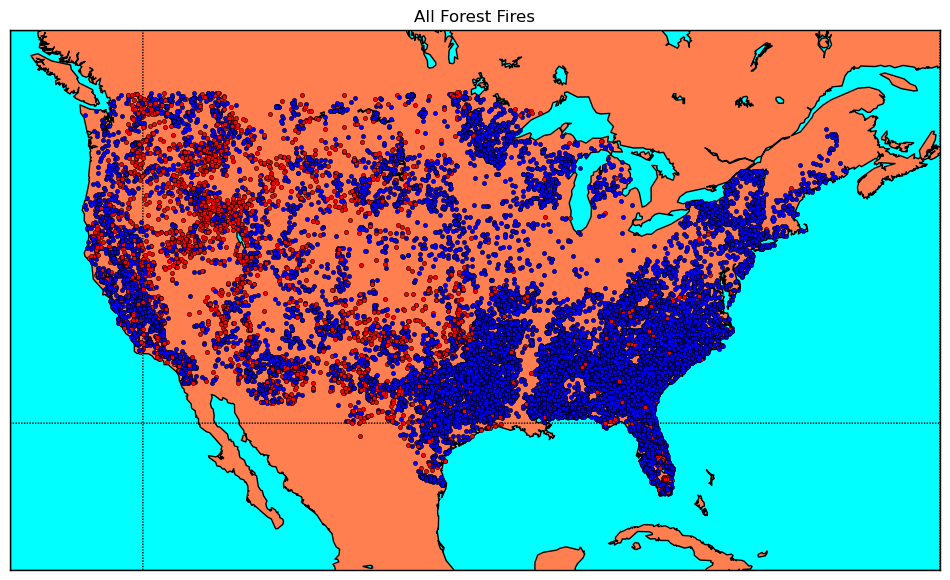

In [4]:
# Plot all the forest fires in the training set.
plt.figure(figsize=(12, 8))
# lon_0 is central longitude of projection.
# resolution = 'c' means use crude resolution coastlines.
m = Basemap(projection='merc',lon_0=-100,resolution='l',lat_0=40, llcrnrlon=-130, llcrnrlat=20, urcrnrlon=-60, urcrnrlat=52)
m.drawcoastlines()
m.fillcontinents(color='coral',lake_color='aqua')
# draw parallels and meridians.
m.drawparallels(np.arange(-90.,120.,30.))
m.drawmeridians(np.arange(0.,360.,60.))
m.drawmapboundary(fill_color='aqua') 
plt.title(f"All Forest Fires")


# Load Tornado Dataset
raw_data_2 = np.loadtxt("data/forest_fires_train.csv", delimiter=",", dtype=str)
df_ff = pd.DataFrame(raw_data_2[1:], columns=raw_data_2[0])

for i in range(len(df_ff)):
    lat = float(df_ff.iloc[i, 0])
    lon = float(df_ff.iloc[i, 1])
    xpt,ypt = m(lon,lat)
    fire_type = int(df_ff.iloc[i, 15])
    if fire_type == 0:
        m.plot(xpt, ypt,'o', markersize='3', color='blue', markeredgewidth = '0.4', markeredgecolor="#000000")
    elif fire_type == 1:
        m.plot(xpt, ypt,'o', markersize='3', color='red', markeredgewidth = '0.4', markeredgecolor="#000000")
plt.show()

([<matplotlib.axis.XTick at 0x316c6f250>,
 [Text(0, 0, '0'),
  Text(4, 0, '4'),
  Text(8, 0, '8'),
  Text(12, 0, '12'),
  Text(16, 0, '16'),
  Text(20, 0, '20')])

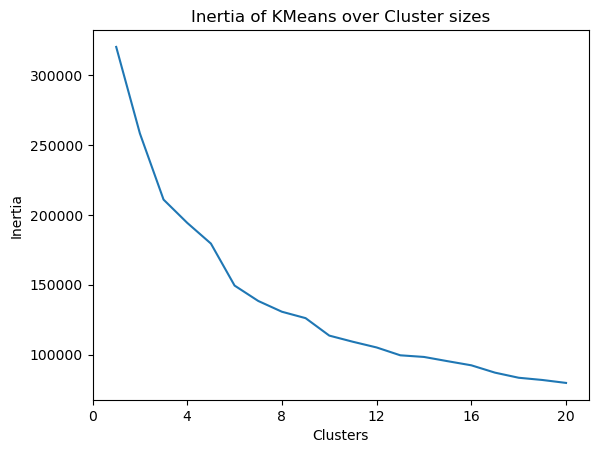

In [10]:
# Attempt K-Means Clustering
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load forest fire data into a DataFrame
forest_fires = pd.read_csv("data/forest_fires_train.csv")

# Store lat/lon in separate df, then drop cols
loc_df = forest_fires.iloc[:, 0:2]
drop_list = ['lat','long','dist_met_station']
kmeans_data = forest_fires.drop(columns=drop_list)

X = kmeans_data.to_numpy()

inertia = []
clusters = 20
for K in range(1,clusters+1):
    scaler = StandardScaler()
    # Create KMeans instance: kmeans
    kmeans = KMeans(n_clusters=K)
    pipeline = make_pipeline(scaler, kmeans)
    pipeline.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,21), inertia)
plt.title('Inertia of KMeans over Cluster sizes')
plt.ylabel('Inertia')
plt.xlabel('Clusters')
plt.xticks([0,4,8,12,16,20])

In [20]:
# Plot an appropriate KMeans cluster size against the US map
np.random.seed(44)

n_k = 6
scaler = StandardScaler()
# Create a KMeans model with 6 clusters: kmeans
kmeans = KMeans(n_clusters=n_k)
pipeline = make_pipeline(scaler, kmeans)
pipeline.fit(X)
# Get labels
labels = pipeline.predict(X)

colors = ['blue', 'purple', 'orange', 'green', 'red', 'cyan']
colors_toplot = []
for label in labels:
    colors_toplot.append(colors[label])

for label in labels:
    colors_toplot.append(colors[label])


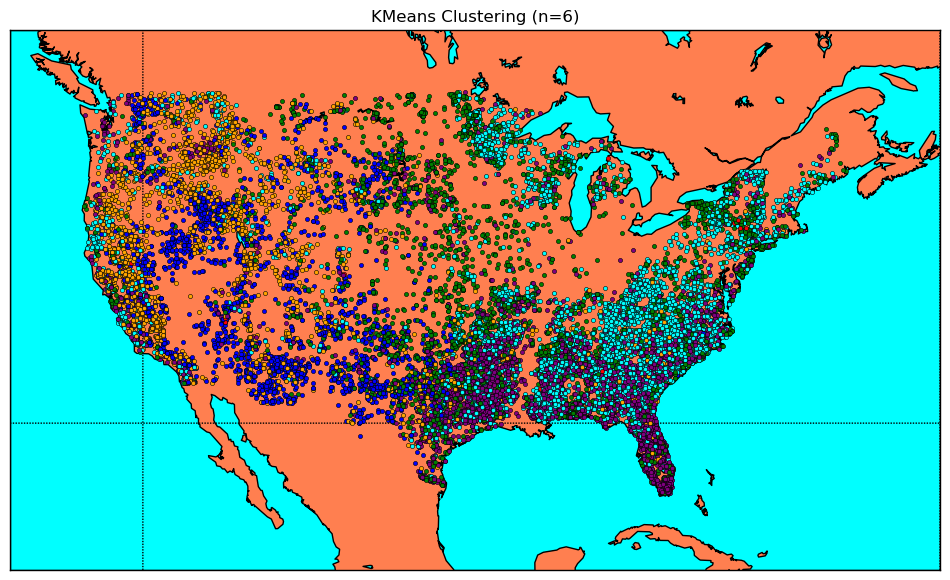

In [21]:
plt.figure(figsize=(12, 8))
m = Basemap(projection='merc',lon_0=-100,resolution='l',lat_0=40, llcrnrlon=-130, llcrnrlat=20, urcrnrlon=-60, urcrnrlat=52)
m.drawcoastlines()
m.fillcontinents(color='coral',lake_color='aqua')
# draw parallels and meridians.
m.drawparallels(np.arange(-90.,120.,30.))
m.drawmeridians(np.arange(0.,360.,60.))
m.drawmapboundary(fill_color='aqua') 

plt.title(f"KMeans Clustering (n={n_k})")

for i in range(len(loc_df)):
    lat = float(loc_df.iloc[i, 0])
    lon = float(loc_df.iloc[i, 1])
    xpt,ypt = m(lon,lat)
    fire_type = int(df_ff.iloc[i, 15])
    m.plot(xpt, ypt,'o', markersize='3', color=colors_toplot[i], markeredgewidth = '0.4', markeredgecolor="#000000")
plt.show()